# 🛢️ Advanced Storage Tank Volume Calculator

*From a plain Python script to an interactive, tested notebook*

---

## 👋 What this notebook does

We calculate the **volume** and **capacity** of a cylindrical oil storage tank, and then take that same
calculation from a throwaway script to something you would be happy to hand to a colleague:

| Stage | What it looks like | Who it is for |
|---|---|---|
| 1️⃣ **A script** | Type numbers, print an answer | You, once |
| 2️⃣ **A tested class** | Validated inputs, checked against known answers | Anyone who must trust the result |
| 3️⃣ **An interactive notebook** | Drag a slider, watch it update | You and your colleagues |

That progression is the real lesson. The engineering is one line of arithmetic. Making it reliable and
usable is the part worth practicing.

## 📐 The engineering

Given a tank of radius $r$ and height $h$ in meters:

$$V = \pi r^2 h \qquad \text{cubic meters}$$

Oil volumes are usually quoted in **barrels**. One cubic meter is about 6.2898 barrels, so:

$$C = 6.2898 \times V \qquad \text{barrels}$$

> 📌 **Where 6.2898 comes from.** One US oil barrel is defined as 42 US gallons, which is
> 0.158987294928 m³. Dividing 1 by that gives 6.28981 barrels per cubic meter.

## 🗺️ Contents

| Part | Topic |
|---|---|
| **1** | 🧰 Setup and constants |
| **2** | 🏗️ The `Tank` class |
| **3** | ✅ Testing the class |
| **4** | 🖥️ The simple script version |
| **5** | 🎛️ **Interactive version with sliders** |
| **6** | 📊 Sensitivity analysis |
| **7** | ✍️ Exercises |
| **8** | 📚 References |

> 🧭 **To jump between parts,** open the outline panel: in **Colab** click the ☰ *Table of contents*
> icon on the left, in **JupyterLab** use the outline sidebar.

---
# 🧰 Part 1: Setup and Constants

Run this cell first. Everything below depends on it.

In [1]:
# Install anything that is missing. Colab already has all of these except ipywidgets
# in some runtimes, so this is quick and safe to run.
# %pip install -q numpy matplotlib ipywidgets

In [2]:
import math

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("✅ Libraries loaded")

✅ Libraries loaded


### 📏 Constants

Named constants beat numbers buried in code. If the conversion factor ever changes, or a grader asks
where 6.2898 came from, there is exactly one place to look.

In [3]:
PI = math.pi                         # more precise than typing 3.14159

BARRELS_PER_CUBIC_METER = 6.2898     # 1 m³ of oil ≈ 6.2898 US barrels
CRUDE_DENSITY_KG_PER_M3 = 850.0      # typical medium crude, used later for mass

print(f"PI                      = {PI:.6f}")
print(f"BARRELS_PER_CUBIC_METER = {BARRELS_PER_CUBIC_METER}")

PI                      = 3.141593
BARRELS_PER_CUBIC_METER = 6.2898


---
# 🏗️ Part 2: The `Tank` Class

A class bundles the tank's **data** (radius, height) with the **calculations** that belong to it. Four
things are worth noticing in the code below, because they are what separates a class you wrote for
yourself from one you would hand to somebody else.

| Feature | Why it is there |
|---|---|
| ✅ **Validation in `__init__`** | A tank cannot have a negative radius. Catch it immediately, not three calculations later |
| 📝 **Docstrings** | `help(Tank)` explains the class to whoever inherits your code |
| 🏷️ **Type hints** | `radius: float` documents intent and lets your editor catch mistakes |
| 🖨️ **`__repr__`** | Printing the object shows something useful instead of a memory address |

In [4]:
class Tank:
    """
    A vertical cylindrical storage tank.

    Parameters
    ----------
    radius : float
        Internal radius in meters. Must be positive.
    height : float
        Internal height in meters. Must be positive.
    name : str, optional
        A tag such as "T-101", used only for display.

    Raises
    ------
    ValueError
        If radius or height is zero or negative.
    """

    def __init__(self, radius: float, height: float, name: str = "Tank"):
        # ── Validate FIRST. Never store values you know are wrong. ────────────
        if radius <= 0:
            raise ValueError(f"radius must be positive, got {radius}")
        if height <= 0:
            raise ValueError(f"height must be positive, got {height}")

        self.radius = float(radius)
        self.height = float(height)
        self.name = name

    # ── Core calculations ────────────────────────────────────────────────────

    def calculate_volume(self) -> float:
        """Total internal volume in cubic meters: V = pi * r^2 * h."""
        return PI * self.radius ** 2 * self.height

    def calculate_capacity(self) -> float:
        """Total capacity in US barrels."""
        return self.calculate_volume() * BARRELS_PER_CUBIC_METER

    # ── Useful extras a real operator would ask for ──────────────────────────

    def volume_at_level(self, level: float) -> float:
        """
        Volume of liquid in cubic meters when filled to `level` meters.

        For a VERTICAL cylinder the cross section is constant, so the volume
        is simply the base area times the liquid depth.
        """
        if not 0 <= level <= self.height:
            raise ValueError(f"level must be between 0 and {self.height} m, got {level}")
        return PI * self.radius ** 2 * level

    def fill_percentage(self, level: float) -> float:
        """What percentage of the tank is full at a given liquid level."""
        return 100.0 * self.volume_at_level(level) / self.calculate_volume()

    def surface_area(self) -> float:
        """
        External surface area in square meters: shell plus roof plus floor.

        Useful for estimating paint, insulation, or coating cost.
        """
        shell = 2 * PI * self.radius * self.height
        ends = 2 * PI * self.radius ** 2
        return shell + ends

    def mass_of_contents(self, level: float = None, density: float = CRUDE_DENSITY_KG_PER_M3) -> float:
        """Mass of the contents in tonnes. Defaults to a completely full tank."""
        level = self.height if level is None else level
        return self.volume_at_level(level) * density / 1000.0

    # ── Display ──────────────────────────────────────────────────────────────

    def __repr__(self) -> str:
        """What Python shows when you print the object."""
        return f"Tank(name={self.name!r}, radius={self.radius} m, height={self.height} m)"

    def summary(self) -> str:
        """A short, readable report on the tank."""
        return (
            f"📋 {self.name}\n"
            f"   Radius        : {self.radius:>10.2f} m\n"
            f"   Height        : {self.height:>10.2f} m\n"
            f"   Volume        : {self.calculate_volume():>10.2f} m³\n"
            f"   Capacity      : {self.calculate_capacity():>10.2f} barrels\n"
            f"   Surface area  : {self.surface_area():>10.2f} m²\n"
            f"   Mass when full: {self.mass_of_contents():>10.2f} tonnes"
        )


print("✅ Tank class defined")

✅ Tank class defined


In [5]:
# Try it out with the tank from the original program
tank = Tank(radius=10.0, height=2.5, name="T-101")

print(tank)            # this calls __repr__
print()
print(tank.summary())

Tank(name='T-101', radius=10.0 m, height=2.5 m)

📋 T-101
   Radius        :      10.00 m
   Height        :       2.50 m
   Volume        :     785.40 m³
   Capacity      :    4940.00 barrels
   Surface area  :     785.40 m²
   Mass when full:     667.59 tonnes


---
# ✅ Part 3: Testing the Class

Before you trust a calculation, check it against an answer you already know. These are `assert`
statements: if the condition is false, Python stops with an error. If everything passes, you see the
success message and nothing else.

> 💡 **This habit costs 2 minutes and saves hours.** A sign error or a units mix-up that you catch here
> is a bug. The same error caught in a report is an embarrassment.

In [6]:
# ── Test 1: a tank with r = 1 and h = 1 should have volume exactly pi ────────
unit_tank = Tank(radius=1.0, height=1.0)
assert math.isclose(unit_tank.calculate_volume(), math.pi), "volume formula is wrong"

# ── Test 2: doubling the radius should QUADRUPLE the volume (r is squared) ───
small = Tank(radius=2.0, height=5.0)
large = Tank(radius=4.0, height=5.0)
assert math.isclose(large.calculate_volume(), 4 * small.calculate_volume()), "r^2 scaling is wrong"

# ── Test 3: doubling the height should DOUBLE the volume (h is linear) ───────
tall = Tank(radius=2.0, height=10.0)
assert math.isclose(tall.calculate_volume(), 2 * small.calculate_volume()), "h scaling is wrong"

# ── Test 4: a full tank is 100% full, an empty one is 0% ────────────────────
assert math.isclose(tank.fill_percentage(tank.height), 100.0)
assert math.isclose(tank.fill_percentage(0.0), 0.0)

# ── Test 5: the original program's answer is reproduced ─────────────────────
assert math.isclose(tank.calculate_volume(), 785.398, rel_tol=1e-4), "does not match the original"

# ── Test 6: invalid tanks must be REJECTED, not silently accepted ────────────
for bad_radius, bad_height in [(-5, 10), (0, 10), (10, -1), (10, 0)]:
    try:
        Tank(bad_radius, bad_height)
    except ValueError:
        pass          # this is the correct behavior
    else:
        raise AssertionError(f"Tank({bad_radius}, {bad_height}) should have been rejected")

print("✅ All 6 tests passed")

✅ All 6 tests passed


---
# 🖥️ Part 4: The Simple Script Version

This is the original program: greet the user, ask for two numbers, print the answer.

> ⚠️ **A warning about `input()` in notebooks.** `input()` stops the whole notebook and waits for
> someone to type. That means:
> - **Kernel → Restart & Run All** hangs instead of finishing.
> - The notebook cannot be graded or tested automatically.
> - In some Colab runtimes the prompt is easy to miss entirely.
>
> The cell below is written with a switch so it runs either way. Leave `ASK_THE_USER = False` for a
> clean run, or set it to `True` when you want to be prompted.

In [7]:
def greet_operator(name: str = "Operator") -> None:
    """Print a welcome banner."""
    print("=" * 52)
    print("  🛢️  Welcome to the Storage Tank Volume Calculator!")
    print(f"  Signed in as: {name}")
    print("=" * 52)


# ── Set this to True if you want to type the numbers yourself ────────────────
ASK_THE_USER = False

greet_operator()

if ASK_THE_USER:
    radius = float(input("Enter the radius of the tank (m): "))
    height = float(input("Enter the height of the tank (m): "))
else:
    radius, height = 10.0, 2.5          # the defaults from the original program
    print(f"\nUsing default values: radius = {radius} m, height = {height} m")

# Create the object and run the calculations
t = Tank(radius, height, name="T-101")
volume = t.calculate_volume()
capacity = t.calculate_capacity()

print(f"\nThe volume of the tank is  : {volume:.2f} cubic meters")
print(f"The capacity of the tank is: {capacity:.2f} barrels")

  🛢️  Welcome to the Storage Tank Volume Calculator!
  Signed in as: Operator

Using default values: radius = 10.0 m, height = 2.5 m

The volume of the tank is  : 785.40 cubic meters
The capacity of the tank is: 4940.00 barrels


### 🛡️ Handling bad input properly

If you do accept typed input, someone will eventually type `"ten"` or `-5`. A loop that keeps asking
until the value is valid is only a few lines, and it is the difference between a script and a tool.

In [8]:
def ask_for_positive_number(prompt: str, default: float) -> float:
    """
    Ask the user for a positive number, repeating until they give one.

    Falls back to `default` if input is unavailable, which keeps the notebook
    runnable from top to bottom without a human present.
    """
    while True:
        try:
            raw = input(prompt)
        except (EOFError, OSError):
            # No console attached, for example during automated execution
            print(f"(no input available, using default {default})")
            return default

        try:
            value = float(raw)
        except ValueError:
            print(f"  ❌ '{raw}' is not a number. Try again.")
            continue

        if value <= 0:
            print(f"  ❌ {value} is not positive. A tank needs a positive size.")
            continue

        return value


# Demonstrate the validation logic without needing a human, by testing the
# checks directly on a few sample strings.
for sample in ["12.5", "ten", "-3", "0", "8"]:
    try:
        value = float(sample)
        verdict = "✅ accepted" if value > 0 else "❌ rejected: not positive"
    except ValueError:
        verdict = "❌ rejected: not a number"
    print(f"  input {sample!r:>8}  ->  {verdict}")

  input   '12.5'  ->  ✅ accepted
  input    'ten'  ->  ❌ rejected: not a number
  input     '-3'  ->  ❌ rejected: not positive
  input      '0'  ->  ❌ rejected: not positive
  input      '8'  ->  ✅ accepted


---
# 🎛️ Part 5: Interactive Version with Sliders

Typing numbers and rerunning a cell is slow. **ipywidgets** turns the same function into something you
can explore by dragging a slider, with the answer updating as you move.

This is the single biggest upgrade you can make to a teaching or analysis notebook, and it is about
five lines of code.

> 📦 **If the sliders do not appear:** run `%pip install ipywidgets` and restart the kernel. In some
> Colab runtimes you may also need `from google.colab import output; output.enable_custom_widget_manager()`.

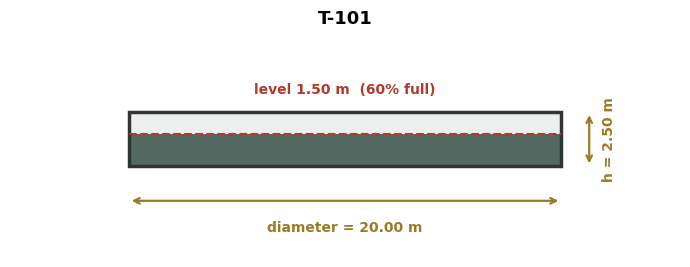

  Total volume    :     785.40 m³
  Total capacity  :    4940.00 barrels
  Liquid volume   :     471.24 m³
  Liquid barrels  :    2964.00 barrels
  Mass of contents:     400.55 tonnes
  Fill            :       60.0 %


In [9]:
# A drawing function we can reuse. It takes plain numbers, so it works with or
# without widgets, and it is easy to test.
def draw_tank(radius: float, height: float, fill_pct: float = 60.0, show_text: bool = True):
    """Draw a labeled side view of the tank with its liquid level."""
    t = Tank(radius, height, name="T-101")
    level = height * fill_pct / 100.0

    # All text offsets are measured against ONE common scale, so the labels stay
    # readable whether the tank is wide and squat or tall and thin.
    scale = max(radius, height)

    # Choose a figure shape that suits the tank's proportions
    aspect = (2 * radius) / height
    fig_w = 7.0
    fig_h = max(3.2, min(7.0, fig_w / max(aspect, 0.35) * 0.85))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # ── Tank shell (a side view of a cylinder is a rectangle of width 2r) ────
    ax.add_patch(plt.Rectangle((-radius, 0), 2 * radius, height,
                               facecolor="#EDEFEE", edgecolor="#333333",
                               linewidth=2.5, zorder=2))

    # ── Liquid ───────────────────────────────────────────────────────────────
    ax.add_patch(plt.Rectangle((-radius, 0), 2 * radius, level,
                               facecolor="#1F3B31", alpha=0.75,
                               edgecolor="none", zorder=3))

    # ── Liquid level line and label, placed above the tank so nothing overlaps
    ax.plot([-radius, radius], [level, level],
            color="#B03A2E", ls="--", lw=1.5, zorder=4)
    ax.text(0, height + 0.07 * scale,
            f"level {level:.2f} m  ({fill_pct:.0f}% full)",
            ha="center", va="bottom", color="#B03A2E", fontweight="bold")

    # ── Diameter arrow, below the tank ───────────────────────────────────────
    y_dim = -0.16 * scale
    ax.annotate("", xy=(-radius, y_dim), xytext=(radius, y_dim),
                arrowprops=dict(arrowstyle="<->", color="#9A7B26", lw=1.6))
    ax.text(0, y_dim - 0.09 * scale, f"diameter = {2 * radius:.2f} m",
            ha="center", va="top", color="#9A7B26", fontweight="bold")

    # ── Height arrow, to the right of the tank ───────────────────────────────
    x_dim = radius + 0.13 * scale
    ax.annotate("", xy=(x_dim, 0), xytext=(x_dim, height),
                arrowprops=dict(arrowstyle="<->", color="#9A7B26", lw=1.6))
    ax.text(x_dim + 0.06 * scale, height / 2, f"h = {height:.2f} m",
            va="center", ha="left", rotation=90,
            color="#9A7B26", fontweight="bold")

    ax.set_xlim(-radius - 0.55 * scale, radius + 0.55 * scale)
    ax.set_ylim(-0.42 * scale, height + 0.32 * scale)
    ax.set_aspect("equal")          # keep true proportions
    ax.axis("off")
    # Note: no emoji in the title. Matplotlib's default font has no glyph for
    # most emoji and would draw an empty box instead.
    ax.set_title(t.name, fontsize=13, fontweight="bold", pad=14)

    plt.tight_layout()
    plt.show()

    if show_text:
        print(f"  Total volume    : {t.calculate_volume():>10.2f} m³")
        print(f"  Total capacity  : {t.calculate_capacity():>10.2f} barrels")
        print(f"  Liquid volume   : {t.volume_at_level(level):>10.2f} m³")
        print(f"  Liquid barrels  : {t.volume_at_level(level) * BARRELS_PER_CUBIC_METER:>10.2f} barrels")
        print(f"  Mass of contents: {t.mass_of_contents(level):>10.2f} tonnes")
        print(f"  Fill            : {fill_pct:>10.1f} %")


# Run it once with fixed numbers, so there is always a visible result even if
# widgets are unavailable in whatever viewer you are using.
draw_tank(radius=10.0, height=2.5, fill_pct=60.0)

### 🎚️ Now add the sliders

`interact` inspects the function's arguments and builds a control for each one. Drag any slider and
the figure and the numbers refresh immediately.

In [10]:
try:
    from ipywidgets import interact, FloatSlider

    interact(
        draw_tank,
        radius=FloatSlider(value=10.0, min=0.5, max=30.0, step=0.5,
                           description="Radius (m)", continuous_update=False),
        height=FloatSlider(value=2.5, min=0.5, max=25.0, step=0.5,
                           description="Height (m)", continuous_update=False),
        fill_pct=FloatSlider(value=60.0, min=0.0, max=100.0, step=1.0,
                             description="Fill (%)", continuous_update=False),
        show_text=True,
    )

except ImportError:
    print("⚠️  ipywidgets is not installed, so the sliders cannot be shown.")
    print("    Install it with:  %pip install ipywidgets   then restart the kernel.")
    print("    In the meantime, call draw_tank(radius, height, fill_pct) directly.")

interactive(children=(FloatSlider(value=10.0, continuous_update=False, description='Radius (m)', max=30.0, min…

> 💡 **`continuous_update=False` matters.** Without it, the figure redraws on every pixel of slider
> movement, which feels laggy. With it, the update happens when you release the slider.

### 🧮 A second interactive tool: what size tank do I need?

The reverse question is the one a planner actually asks. Given a required capacity in barrels and a
site constraint on height, what radius do you need?

In [11]:
def required_radius(target_barrels: float = 5000.0, height: float = 2.5) -> None:
    """Solve V = pi r^2 h for r, given a target capacity in barrels."""
    target_volume = target_barrels / BARRELS_PER_CUBIC_METER      # barrels -> m³
    radius = math.sqrt(target_volume / (PI * height))             # rearranged formula

    t = Tank(radius, height, name="Proposed tank")

    print(f"🎯 Target capacity : {target_barrels:>10.0f} barrels")
    print(f"   Required volume : {target_volume:>10.2f} m³")
    print(f"   Fixed height    : {height:>10.2f} m")
    print(f"\n   ➡️  Required radius : {radius:>7.2f} m  (diameter {2 * radius:.2f} m)")
    print(f"   ➡️  Check           : {t.calculate_capacity():>7.0f} barrels")


# Static example first, so the output is visible even without live widgets
required_radius(target_barrels=5000.0, height=2.5)
print("\n" + "-" * 52 + "\n")

try:
    from ipywidgets import interact, FloatSlider

    interact(
        required_radius,
        target_barrels=FloatSlider(value=5000, min=500, max=50000, step=500,
                                   description="Target (bbl)", continuous_update=False),
        height=FloatSlider(value=2.5, min=1.0, max=25.0, step=0.5,
                           description="Height (m)", continuous_update=False),
    )

except ImportError:
    print("⚠️  ipywidgets is not installed, so the sliders cannot be shown.")
    print("    Call required_radius(target_barrels, height) directly instead.")

🎯 Target capacity :       5000 barrels
   Required volume :     794.94 m³
   Fixed height    :       2.50 m

   ➡️  Required radius :   10.06 m  (diameter 20.12 m)
   ➡️  Check           :    5000 barrels

----------------------------------------------------



interactive(children=(FloatSlider(value=5000.0, continuous_update=False, description='Target (bbl)', max=50000…

---
# 📊 Part 6: Sensitivity Analysis

One number is an answer. A **curve** is an insight. These two plots show something the formula states
but people still get wrong in practice: radius and height do not matter equally.

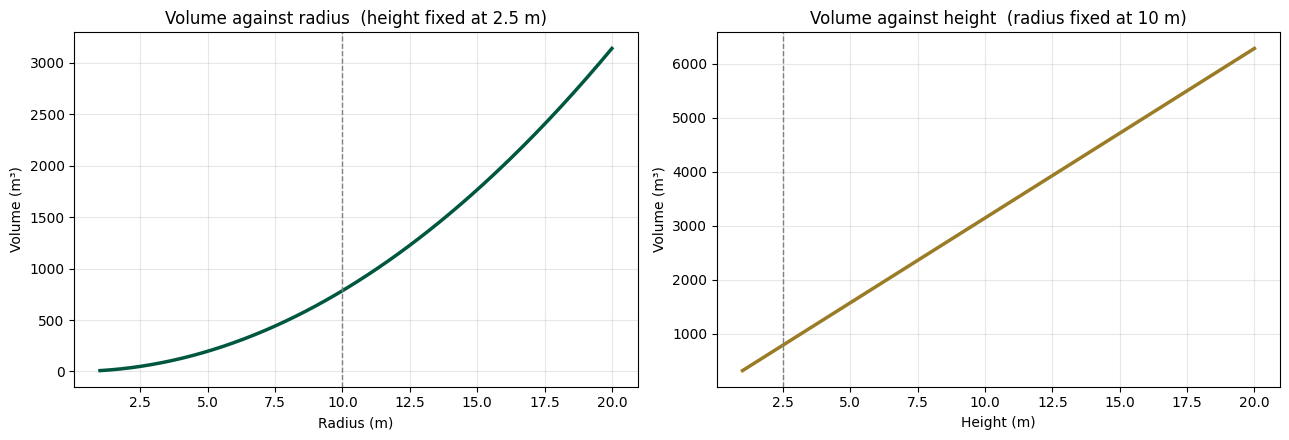

👀 The left curve bends upward, the right one is a straight line.
   Volume grows with the SQUARE of the radius but only LINEARLY with height.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: vary the radius, hold the height fixed ─────────────────────────────
radii = np.linspace(1, 20, 200)
volumes_r = PI * radii ** 2 * 2.5                 # h fixed at 2.5 m

axes[0].plot(radii, volumes_r, lw=2.5, color="#00573F")
axes[0].axvline(10, ls="--", color="grey", lw=1)
axes[0].set_title("Volume against radius  (height fixed at 2.5 m)")
axes[0].set_xlabel("Radius (m)")
axes[0].set_ylabel("Volume (m³)")

# ── Right: vary the height, hold the radius fixed ────────────────────────────
heights = np.linspace(1, 20, 200)
volumes_h = PI * 10 ** 2 * heights                # r fixed at 10 m

axes[1].plot(heights, volumes_h, lw=2.5, color="#9A7B26")
axes[1].axvline(2.5, ls="--", color="grey", lw=1)
axes[1].set_title("Volume against height  (radius fixed at 10 m)")
axes[1].set_xlabel("Height (m)")
axes[1].set_ylabel("Volume (m³)")

plt.tight_layout()
plt.show()

print("👀 The left curve bends upward, the right one is a straight line.")
print("   Volume grows with the SQUARE of the radius but only LINEARLY with height.")

In [13]:
# Put a number on it: what does a 10% increase in each dimension buy you?
base = Tank(10.0, 2.5)
wider = Tank(10.0 * 1.10, 2.5)
taller = Tank(10.0, 2.5 * 1.10)

base_v = base.calculate_volume()

print(f"Base tank (r=10.0, h=2.50)      : {base_v:8.2f} m³")
print(f"Radius +10% (r=11.0, h=2.50)    : {wider.calculate_volume():8.2f} m³"
      f"   -> {(wider.calculate_volume() / base_v - 1):+.1%}")
print(f"Height +10% (r=10.0, h=2.75)    : {taller.calculate_volume():8.2f} m³"
      f"   -> {(taller.calculate_volume() / base_v - 1):+.1%}")
print("\n📌 Ten percent more radius buys you 21% more volume. Ten percent more height buys 10%.")
print("   That is why storage tanks are usually wide and squat rather than tall and thin.")

Base tank (r=10.0, h=2.50)      :   785.40 m³
Radius +10% (r=11.0, h=2.50)    :   950.33 m³   -> +21.0%
Height +10% (r=10.0, h=2.75)    :   863.94 m³   -> +10.0%

📌 Ten percent more radius buys you 21% more volume. Ten percent more height buys 10%.
   That is why storage tanks are usually wide and squat rather than tall and thin.


In [14]:
# ── A calibration table an operator could actually tape to the tank ──────────
print(f"{'Level (m)':>10} {'Volume (m³)':>13} {'Barrels':>12} {'Fill (%)':>10}")
print("=" * 48)

for lvl in np.arange(0, tank.height + 0.001, 0.25):
    v = tank.volume_at_level(lvl)
    print(f"{lvl:>10.2f} {v:>13.2f} {v * BARRELS_PER_CUBIC_METER:>12.1f} "
          f"{tank.fill_percentage(lvl):>10.1f}")

 Level (m)   Volume (m³)      Barrels   Fill (%)
      0.00          0.00          0.0        0.0
      0.25         78.54        494.0       10.0
      0.50        157.08        988.0       20.0
      0.75        235.62       1482.0       30.0
      1.00        314.16       1976.0       40.0
      1.25        392.70       2470.0       50.0
      1.50        471.24       2964.0       60.0
      1.75        549.78       3458.0       70.0
      2.00        628.32       3952.0       80.0
      2.25        706.86       4446.0       90.0
      2.50        785.40       4940.0      100.0


---
# ✍️ Part 7: Exercises

> **✅ Exercise 1: Horizontal tanks**
>
> Many tanks lie on their side. For a horizontal cylinder of radius $r$ and length $L$, filled to depth
> $d$, the liquid volume is:
>
> $$V = L \left[ r^2 \arccos\!\left(\frac{r-d}{r}\right) - (r-d)\sqrt{2rd - d^2} \right]$$
>
> Add a `HorizontalTank` class with this formula. Check that a half-full horizontal tank holds exactly
> half its total volume.

> **✅ Exercise 2: A cost calculator**
>
> Extend `Tank` with a method `coating_cost(price_per_m2)` that uses `surface_area()`. Then add a slider
> for the price and show the cost in the interactive section.

> **✅ Exercise 3: A tank farm**
>
> Create a list of five `Tank` objects with different sizes. Build a pandas DataFrame of their volumes
> and capacities, sort it by capacity, and plot a horizontal bar chart of the farm's total storage.

> **✅ Exercise 4: Choose the product**
>
> Crude is not the only thing stored in tanks. Add a `Dropdown` widget to the interactive section
> offering crude (850 kg/m³), diesel (840 kg/m³), and gasoline (740 kg/m³), and have the mass of
> contents update with the selection.
>
> *Hint: `from ipywidgets import Dropdown`, then pass
> `product=Dropdown(options=[("Crude", 850), ("Diesel", 840), ("Gasoline", 740)])` to `interact`.*

> **✅ Exercise 5: A high level alarm**
>
> Operators care about the last 10% far more than the first 90%. Modify `draw_tank` so that the liquid
> turns red and a warning line is printed when the fill level goes above 90%.
>
> Then add a horizontal line at the 90% mark to the diagram, labeled "high level alarm".

---
# 📚 Part 8: References

### 🔧 Tools used here

| Tool | Documentation |
|---|---|
| ipywidgets | https://ipywidgets.readthedocs.io/ |
| ipywidgets widget list | https://ipywidgets.readthedocs.io/en/stable/examples/Widget%20List.html |
| Matplotlib | https://matplotlib.org/stable/tutorials/index.html |
| Matplotlib patches (shapes) | https://matplotlib.org/stable/api/patches_api.html |
| NumPy | https://numpy.org/doc/stable/user/absolute_beginners.html |

### 📖 Going further

- **Python classes**, the official tutorial: https://docs.python.org/3/tutorial/classes.html
- **Type hints**, what the annotations mean: https://docs.python.org/3/library/typing.html
- **Writing real tests** with pytest, once `assert` statements are no longer enough:
  https://docs.pytest.org/

### 🧾 Unit reference

| Quantity | Conversion |
|---|---|
| 1 US oil barrel | 0.158987294928 m³ = 42 US gallons |
| 1 m³ | 6.28981 barrels |
| 1 m³ of crude at 850 kg/m³ | 0.85 tonnes |

---

**📚 ISE 518 · Data Analytics for Reliability and Maintenance**
**🏛️ King Fahd University of Petroleum and Minerals**

🛢️ *Storage Tank Volume Calculator. From a script to an interactive, tested notebook.*